In [68]:
import certifi
print(certifi.where())

C:\python_study\AI\.venv\Lib\site-packages\certifi\cacert.pem


In [69]:
import os, certifi
os.environ["SSL_CERT_FILE"] = certifi.where()

In [70]:
import pandas as pd
wine = pd.read_csv('https://bit.ly/wine_csv_data')
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [71]:
import sys, ssl
print(sys.executable)
print(ssl.OPENSSL_VERSION)

C:\python_study\AI\.venv\Scripts\python.exe
OpenSSL 1.1.1s  1 Nov 2022


In [72]:
wine. info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [73]:
wine.info()


<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [74]:
wine.describe()  # 통계


,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [75]:
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()
print(data)
print(target)
print(type(data))
print(type(target))

[[ 9.4   1.9   3.51]
 [ 9.8   2.6   3.2 ]
 [ 9.8   2.3   3.26]
 ...
 [ 9.4   1.2   2.99]
 [12.8   1.1   3.34]
 [11.8   0.8   3.26]]
[0. 0. 0. ... 1. 1. 1.]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [76]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)
print(train_input.shape, test_input.shape)

(5197, 3) (1300, 3)


In [77]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)
print(train_scaled)
print('--------------')
print(test_scaled)

[[ 0.01376574  0.4646116  -0.16888369]
 [ 1.60871671 -0.70299854  0.26967864]
 [ 1.10504798 -0.70299854  1.20945505]
 ...
 [-0.82568214  0.0267578   0.14437512]
 [-0.82568214  0.52716215 -0.23153545]
 [-0.82568214 -0.57789745  1.83597265]]
--------------
[[ 1.44082714  1.52797084  0.26967864]
 [-0.48990299 -0.68214836  0.3323304 ]
 [ 1.27293756  0.40206106 -0.23153545]
 ...
 [ 1.60871671 -0.76554908 -0.16888369]
 [-0.90962693  0.88161523  0.52028568]
 [-1.49724045  2.09092573 -1.98578474]]


In [78]:
from sklearn.linear_model import LinearRegression, LogisticRegression

lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))


0.7808350971714451
0.7776923076923077


In [79]:
print(lr.coef_)
print(lr.intercept_)

[[ 0.51268071  1.67335441 -0.68775646]]
[1.81773456]


In [80]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(train_scaled, train_target)
print(dtc.score(train_scaled, train_target))
print(dtc.score(test_scaled, test_target))



0.996921300750433
0.8592307692307692


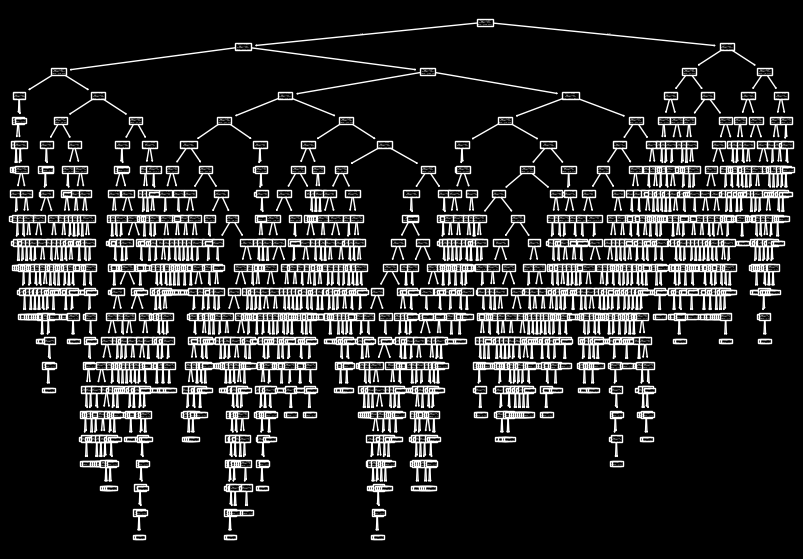

In [81]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10, 7))
plot_tree(dtc)
plt.show()


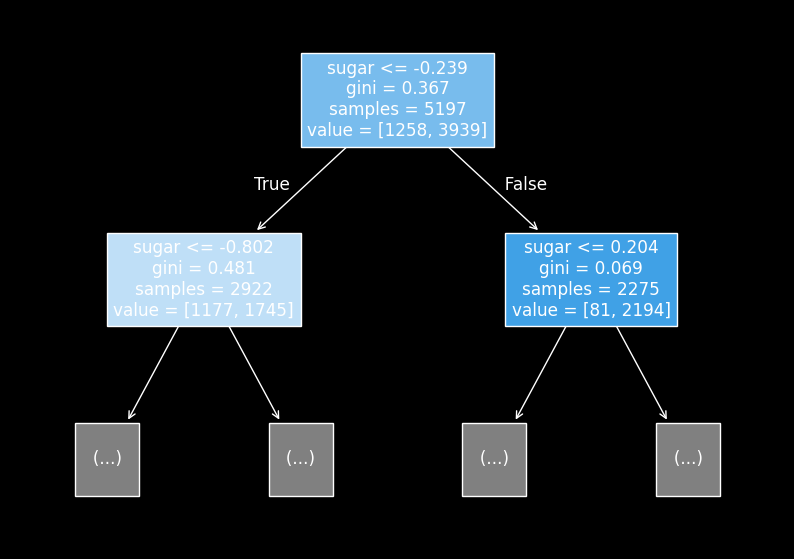

In [82]:
plt.figure(figsize=(10,7))
plot_tree(dtc, max_depth=1, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()


In [83]:
dtc = DecisionTreeClassifier(max_depth=3, random_state=42)
dtc.fit(train_scaled, train_target)
print(dtc.score(train_scaled, train_target))
print(dtc.score(test_scaled, test_target))

0.8454877814123533
0.8415384615384616


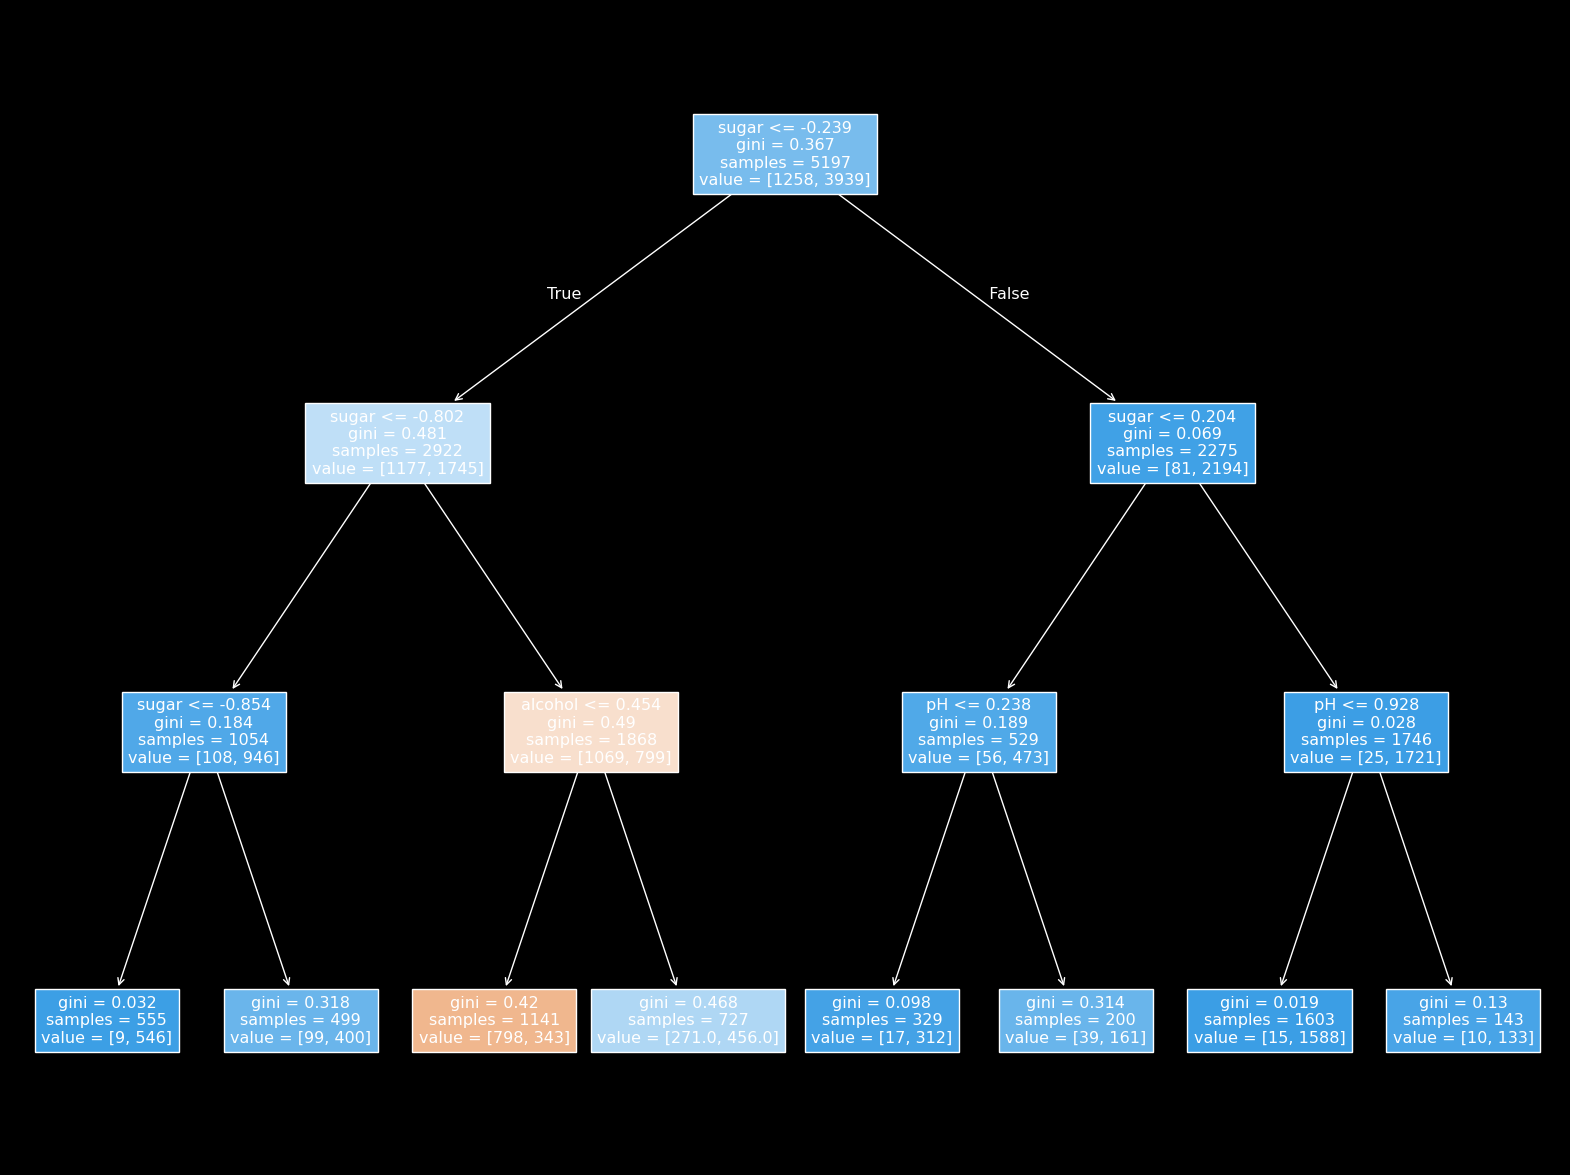

In [84]:
plt.figure(figsize=(20,15))
plot_tree(dtc, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [85]:
import pandas as pd
wine = pd.read_csv('https://bit.ly/wine_csv_data')
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()

In [86]:
target = wine['class'].to_numpy()

In [87]:

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)
print(train_input.shape, test_input.shape)

(5197, 3) (1300, 3)


In [88]:
sub_input, val_input, sub_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

print(sub_input.shape, val_input.shape)

(4157, 3) (1040, 3)


In [89]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(sub_input, sub_target)
print(dtc.score(sub_input, sub_target))
print(dtc.score(val_input, val_target))


0.9971133028626413
0.864423076923077


In [90]:
from sklearn.model_selection import cross_validate

scores = cross_validate(dtc, train_input, train_target, cv=5)
print(scores)

{'fit_time': array([0.00403047, 0.0018177 , 0.        , 0.        , 0.01612639]), 'score_time': array([0.00201249, 0.        , 0.        , 0.        , 0.        ]), 'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}


In [91]:
import  numpy as np
print(np.mean(scores['test_score']))

0.855300214703487


In [92]:
from sklearn.model_selection import  StratifiedKFold
splitter = StratifiedKFold()
scores = cross_validate(dtc, train_input, train_target, cv=splitter)
print(scores)

{'fit_time': array([0.00503302, 0.00601101, 0.00575399, 0.00501776, 0.00442362]), 'score_time': array([0.        , 0.        , 0.00100255, 0.        , 0.0010283 ]), 'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}
